In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_with_sentiment.csv")

# Work only on negative reviews — these are the business-critical ones
neg = df[df['hf_sentiment'] == 'negative']['text'].dropna().reset_index(drop=True)

print(f"Total reviews: {len(df):,}")
print(f"Negative reviews: {len(neg):,} ({round(len(neg)/len(df)*100, 1)}%)")

Total reviews: 104,986
Negative reviews: 19,070 (18.2%)


In [2]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    min_df=5,
    ngram_range=(1, 2)   # captures "battery life", "stopped working" etc.
)

X = vectorizer.fit_transform(neg)
print(f"Matrix shape: {X.shape}")
print("Vectorization done ✓")

Matrix shape: (19070, 1000)
Vectorization done ✓


In [3]:
print("Running LDA... (~2 min)")
lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    max_iter=20,
    learning_method='batch'
)
lda.fit(X)
print("Done ✓")

# Print top words per topic
feature_names = vectorizer.get_feature_names_out()
print("\n=== COMPLAINT THEMES ===")
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-12:]][::-1]
    print(f"\nTheme {i+1}: {', '.join(top_words)}")

Running LDA... (~2 min)
Done ✓

=== COMPLAINT THEMES ===

Theme 1: work, did, fit, does, did work, waste, doesn, waste money, money, does work, doesn work, didn

Theme 2: br, br br, work, device, just, product, time, drive, support, use, amazon, tried

Theme 3: working, stopped, months, stopped working, worked, charge, broke, battery, weeks, month, days, lasted

Theme 4: case, screen, didn, keyboard, ipad, didn work, cover, like, cheap, tablet, mouse, work

Theme 5: br, camera, broken, came, product, received, light, item, use, like, just, picture

Theme 6: sound, quality, br, ear, headphones, good, poor, volume, speaker, sound quality, pair, speakers


=== COMPLAINT VOLUME BY THEME ===
theme_name
Device & connectivity issues       6056
Defective on arrival               3232
Audio & sound quality              2911
Durability & battery life          2753
Doesn't work as advertised         2079
Accessories fit & compatibility    2039
Name: count, dtype: int64

Total negative reviews: 19,070


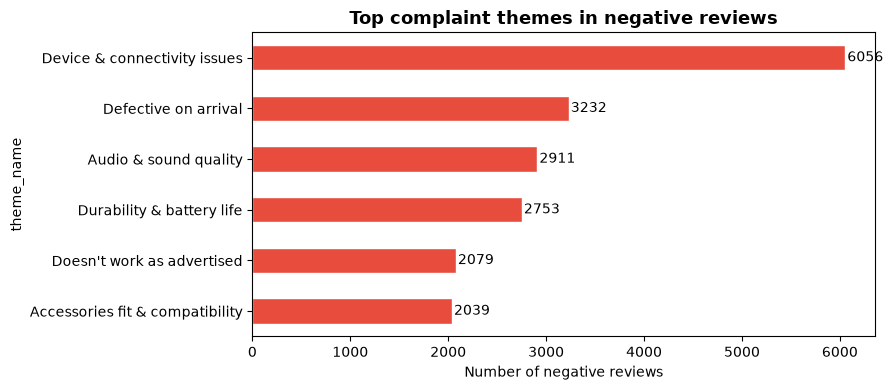

In [4]:
# Assign dominant theme to each negative review
topic_assignments = lda.transform(X)
neg_df = pd.DataFrame({'text': neg})
neg_df['theme_id'] = topic_assignments.argmax(axis=1)

# Name the themes
theme_names = {
    0: "Doesn't work as advertised",
    1: "Device & connectivity issues",
    2: "Durability & battery life",
    3: "Accessories fit & compatibility",
    4: "Defective on arrival",
    5: "Audio & sound quality"
}
neg_df['theme_name'] = neg_df['theme_id'].map(theme_names)

# Count per theme
theme_counts = neg_df['theme_name'].value_counts()
print("=== COMPLAINT VOLUME BY THEME ===")
print(theme_counts)
print(f"\nTotal negative reviews: {len(neg_df):,}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E74C3C', '#E67E22', '#E74C3C', '#C0392B', '#E67E22', '#E74C3C']
theme_counts.plot(kind='barh', ax=ax, color='#E74C3C', edgecolor='white')
ax.set_xlabel("Number of negative reviews")
ax.set_title("Top complaint themes in negative reviews", fontsize=13, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(theme_counts):
    ax.text(v + 20, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig(r"C:\Users\keert\Projects\BA_1\data\complaint_themes.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print("=== 2 SAMPLE REVIEWS PER THEME ===\n")
for theme_id, theme_name in theme_names.items():
    samples = neg_df[neg_df['theme_id'] == theme_id]['text'].sample(
        min(2, len(neg_df[neg_df['theme_id'] == theme_id])), 
        random_state=42
    )
    print(f"--- {theme_name} ---")
    for s in samples:
        print(f"  {str(s)[:180]}")
    print()

=== 2 SAMPLE REVIEWS PER THEME ===

--- Doesn't work as advertised ---
  It did not work at all, It did not even charge. In refund process...
  didn't work!

--- Device & connectivity issues ---
  Unfortunately this case is not worth even the shipping money if they would give it out for free... The plastic is extremely brittle, even when it arrived from shipping you could st
  First one had connection problems at remote end after one month of use. Replacement had connection problems at jack after one month of use. I'm willing to believe it's me, but I ha

--- Durability & battery life ---
  They stop working after a week
  Not worth your time or money.  The software is buggy and took me a few hours to get everything working properly.  After about 3 months of use, the keyboard stopped working, and the

--- Accessories fit & compatibility ---
  Case is great and the keyboard is nice.  The only complaint I have is that the wrong cord was sent with the product so I can not charge my keyboa

In [6]:
# Save neg_df with themes for use in Streamlit app later
neg_df.to_csv(r"C:\Users\keert\Projects\BA_1\data\negative_reviews_with_themes.csv", index=False)

# Save theme counts as a simple summary
theme_counts.to_csv(r"C:\Users\keert\Projects\BA_1\data\theme_counts.csv", header=True)
print("Saved ✓")

Saved ✓


In [7]:
import anthropic
import os
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

# Build structured summary from your real numbers
total        = len(df)
neg_count    = len(neg_df)
neg_pct      = round(neg_count / total * 100, 1)
avg_rating   = round(df['rating'].mean(), 2)
top_theme    = theme_counts.index[0]
top_theme_n  = theme_counts.iloc[0]
top_theme_pct= round(top_theme_n / neg_count * 100, 1)

prompt = f"""You are a senior product analyst at an electronics marketplace.
Below is a statistical summary from analyzing {total:,} customer reviews.
Write a concise product health brief (max 300 words) for the VP of Electronics.

KEY METRICS:
- Total reviews analyzed: {total:,}
- Average star rating: {avg_rating} / 5
- Negative reviews: {neg_count:,} ({neg_pct}%)

TOP COMPLAINT THEMES (ranked by volume):
1. Device & connectivity issues — 6,056 reviews (32%)
2. Defective on arrival — 3,232 reviews (17%)
3. Audio & sound quality — 2,911 reviews (15%)
4. Durability & battery life — 2,753 reviews (14%)
5. Doesn't work as advertised — 2,079 reviews (11%)
6. Accessories fit & compatibility — 2,039 reviews (11%)

FORMAT YOUR RESPONSE EXACTLY AS:
EXECUTIVE SUMMARY
[2 sentences]

TOP 3 CRITICAL ISSUES
1. [issue + business impact]
2. [issue + business impact]
3. [issue + business impact]

RECOMMENDED ACTIONS
1. [specific action for the team]
2. [specific action for the team]
3. [specific action for the team]

RISK IF UNADDRESSED
[1-2 sentences]
"""

message = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=600,
    messages=[{"role": "user", "content": prompt}]
)

brief = message.content[0].text
print(brief)

# Save it
os.makedirs(r"C:\Users\keert\Projects\BA_1\memos", exist_ok=True)
with open(r"C:\Users\keert\Projects\BA_1\memos\ai_product_brief.txt", "w") as f:
    f.write(brief)
print("\nSaved to memos/ai_product_brief.txt ✓")

EXECUTIVE SUMMARY
Analysis of 104,986 customer reviews reveals a solid average rating of 4.08/5, but an 18.2% negative review rate (19,070 reviews) signals meaningful quality and reliability gaps that warrant immediate attention. Complaint patterns point to systemic product integrity issues rather than isolated incidents, suggesting upstream supplier and QC failures.

TOP 3 CRITICAL ISSUES
1. **Device & connectivity issues (32% of complaints)** — The single largest driver of dissatisfaction, affecting an estimated 6,056 customers; persistent connectivity failures erode trust and elevate return rates and support costs.
2. **Defective on arrival (17% of complaints)** — Nearly 1-in-6 negative reviewers received non-functional products, directly damaging brand perception and inflating reverse logistics expenses.
3. **Audio & sound quality (15% of complaints)** — Underperforming core functionality suggests specification misrepresentation or manufacturing inconsistency, compounding the "does

In [8]:
# Run in any notebook cell
print("=== PROJECT 1A SUMMARY ===")
print(f"Dataset: 104,986 reviews")
print(f"Avg rating: 4.08 / 5")
print(f"Negative reviews: 19,070 (18.2%)")
print(f"TextBlob accuracy: 67.4% | F1: 0.442")
print(f"HuggingFace accuracy: 80.4% | F1: 0.613")
print(f"\nTop complaint theme: Device & connectivity issues (32%)")
print(f"Most actionable: Defective on arrival (17%) — direct QC fix")
print("\nFiles saved:")
print(f"  data/amazon_reviews_with_sentiment.csv")
print(f"  data/negative_reviews_with_themes.csv")
print(f"  data/theme_counts.csv")
print(f"  data/complaint_themes.png")
print(f"  data/model_comparison.png")
print(f"  memos/ai_product_brief.txt")

=== PROJECT 1A SUMMARY ===
Dataset: 104,986 reviews
Avg rating: 4.08 / 5
Negative reviews: 19,070 (18.2%)
TextBlob accuracy: 67.4% | F1: 0.442
HuggingFace accuracy: 80.4% | F1: 0.613

Top complaint theme: Device & connectivity issues (32%)
Most actionable: Defective on arrival (17%) — direct QC fix

Files saved:
  data/amazon_reviews_with_sentiment.csv
  data/negative_reviews_with_themes.csv
  data/theme_counts.csv
  data/complaint_themes.png
  data/model_comparison.png
  memos/ai_product_brief.txt
